In [18]:
!python --version

Python 3.11.12


In [19]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import kagglehub

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("kagglehub:", kagglehub.__version__)


pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
kagglehub: 0.3.12


In [20]:
# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/insurance


In [21]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [23]:
#수치형 변수 요약
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


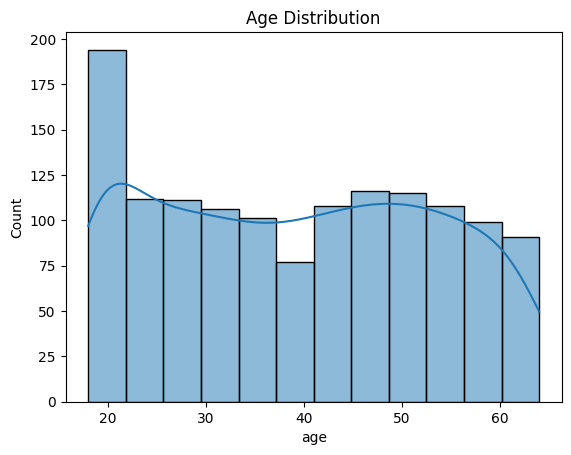

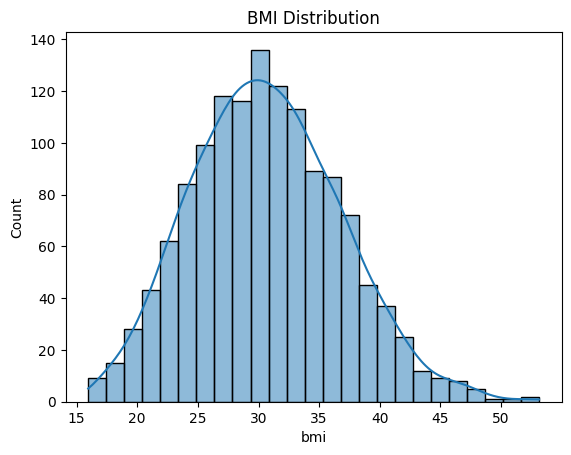

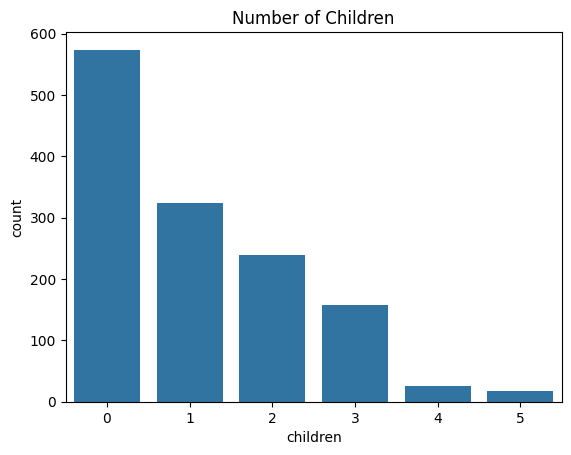

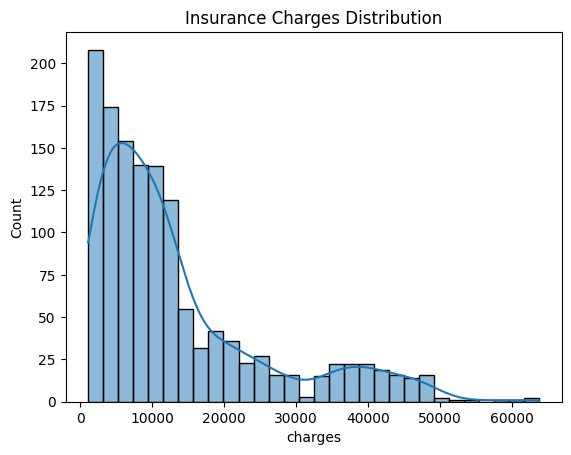

In [24]:
# 나이 분포
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# BMI 분포
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

# Children 분포
sns.countplot(x='children', data=df)
plt.title("Number of Children")
plt.show()

# Charges 분포
sns.histplot(df['charges'], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()


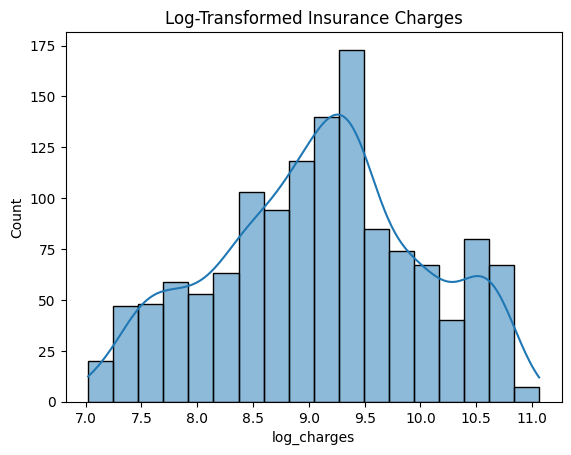

In [25]:
df['log_charges'] = np.log1p(df['charges'])

# 확인: 변환된 분포 시각화
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['log_charges'], kde=True)
plt.title("Log-Transformed Insurance Charges")
plt.show()


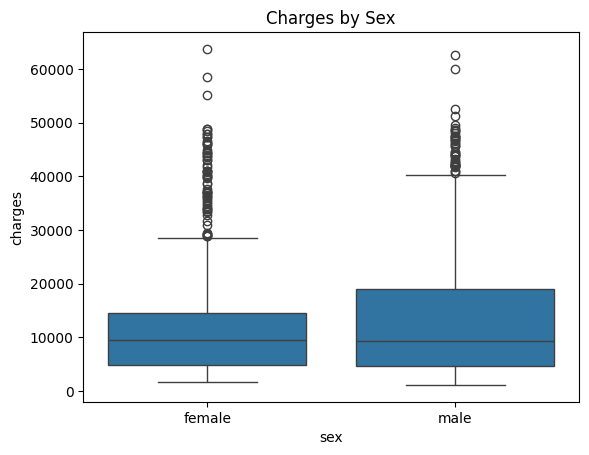

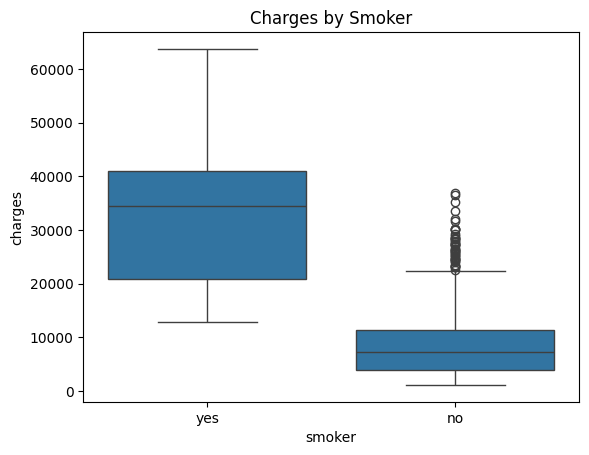

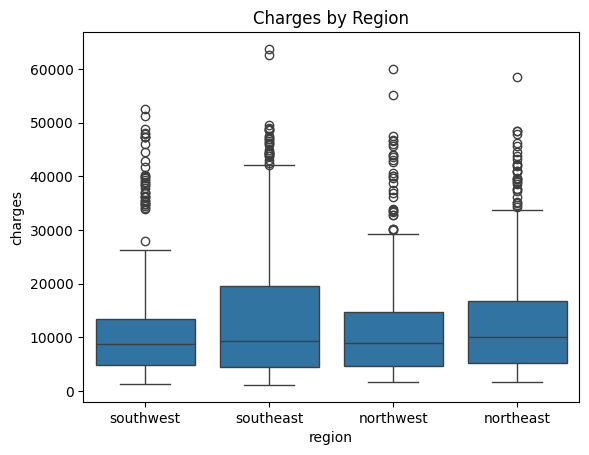

In [26]:
# 성별에 따른 보험료 차이
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex')
plt.show()

# 흡연 여부에 따른 보험료 차이
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker')
plt.show()

# 지역별 보험료 차이
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()


In [27]:
# 원-핫 인코딩 적용
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [28]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, make_scorer
)

# Feature / Target 설정
X = df_encoded.drop(['charges', 'log_charges'], axis=1)
y = df_encoded['log_charges']

# Train/Validation/Test 분할
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cross Validation 세팅
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metric 정의
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Scorers
rmse_scorer = make_scorer(rmse, greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Random Forest 모델
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# CV Metrics (log scale)
rf_cv_rmse = -cross_val_score(rf_model, X_temp, y_temp, scoring=rmse_scorer, cv=kf).mean()
rf_cv_mae = -cross_val_score(rf_model, X_temp, y_temp, scoring=mae_scorer, cv=kf).mean()
rf_cv_r2 = cross_val_score(rf_model, X_temp, y_temp, scoring=r2_scorer, cv=kf).mean()

print("Random Forest CV 평균 (log scale)")
print(" - RMSE:", rf_cv_rmse)
print(" - MAE :", rf_cv_mae)
print(" - R²  :", rf_cv_r2)

# Test 평가 (actual charges 기준)
rf_model.fit(X_temp, y_temp)
rf_pred_log = rf_model.predict(X_test)

# inverse transform
rf_pred_actual = np.expm1(rf_pred_log)
rf_true_actual = np.expm1(y_test)

rf_rmse_actual = rmse(rf_true_actual, rf_pred_actual)
rf_mae_actual = mean_absolute_error(rf_true_actual, rf_pred_actual)
rf_r2_actual = r2_score(rf_true_actual, rf_pred_actual)

print("\nRandom Forest Test (actual charges)")
print(" - RMSE:", rf_rmse_actual)
print(" - MAE :", rf_mae_actual)
print(" - R²  :", rf_r2_actual)

# Linear Regression 모델
lr_model = LinearRegression()

lr_cv_rmse = -cross_val_score(lr_model, X_temp, y_temp, scoring=rmse_scorer, cv=kf).mean()
lr_cv_mae = -cross_val_score(lr_model, X_temp, y_temp, scoring=mae_scorer, cv=kf).mean()
lr_cv_r2 = cross_val_score(lr_model, X_temp, y_temp, scoring=r2_scorer, cv=kf).mean()

print("\nLinear Regression CV 평균 (log scale)")
print(" - RMSE:", lr_cv_rmse)
print(" - MAE :", lr_cv_mae)
print(" - R²  :", lr_cv_r2)

lr_model.fit(X_temp, y_temp)
lr_pred_log = lr_model.predict(X_test)

lr_pred_actual = np.expm1(lr_pred_log)

lr_rmse_actual = rmse(rf_true_actual, lr_pred_actual)
lr_mae_actual = mean_absolute_error(rf_true_actual, lr_pred_actual)
lr_r2_actual = r2_score(rf_true_actual, lr_pred_actual)

print("\nLinear Regression Test (actual charges)")
print(" - RMSE:", lr_rmse_actual)
print(" - MAE :", lr_mae_actual)
print(" - R²  :", lr_r2_actual)


Random Forest CV 평균 (log scale)
 - RMSE: 0.40894577393050896
 - MAE : 0.21809880448487723
 - R²  : 0.7961193596694436

Random Forest Test (actual charges)
 - RMSE: 4359.663522102877
 - MAE : 2090.105777909794
 - R²  : 0.8775728094953124

Linear Regression CV 평균 (log scale)
 - RMSE: 0.4514337329896768
 - MAE : 0.28464243217726815
 - R²  : 0.7526660675942042

Linear Regression Test (actual charges)
 - RMSE: 7814.064025999215
 - MAE : 3888.443158799983
 - R²  : 0.6066982575915569
